In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
# Function to plot metrics
def plot_metric(epochs, y_values, ylabel, title):
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, y_values, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()
def plot_trainNval_metric(epochs, y_values_train, y_values_val, ylabel, title):
    plt.figure(figsize=(5, 3))
    plt.plot(epochs, y_values_train, marker='o', label="val")
    plt.plot(epochs, y_values_val, marker='o', label="test")
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
def plot_trainNvalNtest_metric(epochs, y_values_train, y_values_val, y_values_test, ylabel, title):
    plt.figure(figsize=(5, 3))
    plt.plot(epochs, y_values_train, marker='o', label="train")
    plt.plot(epochs, y_values_val, marker='o', label="val")
    plt.plot(epochs, y_values_test, marker='o', label="test")
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
def get_metrics(file, metrics, is_motor=False):
    # 使用字典来存储每个epoch的最新数据（处理重复训练的情况）
    epoch_data = {}
    
    with open(file, 'r') as f:
        for line in f:
            entry = json.loads(line.strip())  # Parse each line as JSON
            epoch = entry['epoch']
            # 对于相同的epoch，保留最后一次出现的记录（覆盖之前的）
            epoch_data[epoch] = entry
    
    # 按epoch排序，转换为列表
    sorted_epochs = sorted(epoch_data.keys())
    epochs = []
    confusion_matrices = []  # 存储每个epoch的混淆矩阵
    
    for epoch in sorted_epochs:
        entry = epoch_data[epoch]
        epochs.append(epoch)
        metrics['train_loss'].append(entry['train_loss'])
        metrics['val_loss'].append(entry['val_loss'])
        metrics['test_loss'].append(entry['test_loss'])
        metrics['train_class_acc'].append(entry['train_class_acc'])
        metrics['val_accuracy'].append(entry['val_accuracy'])
        metrics['test_accuracy'].append(entry['test_accuracy'])
        
        if is_motor:
            # Motor数据集使用多分类指标
            metrics['val_balanced_accuracy'].append(entry.get('val_balanced_accuracy', 0))
            metrics['test_balanced_accuracy'].append(entry.get('test_balanced_accuracy', 0))
            metrics['val_cohen_kappa'].append(entry.get('val_cohen_kappa', 0))
            metrics['test_cohen_kappa'].append(entry.get('test_cohen_kappa', 0))
            metrics['val_f1_weighted'].append(entry.get('val_f1_weighted', 0))
            metrics['test_f1_weighted'].append(entry.get('test_f1_weighted', 0))
            
            # 读取混淆矩阵（如果存在）
            if 'test_confusion_matrix' in entry:
                confusion_matrices.append({
                    'epoch': epoch,
                    'cm': np.array(entry['test_confusion_matrix'])
                })
        else:
            # 二分类任务使用roc_auc和pr_auc
            metrics['val_roc_auc'].append(entry.get('val_roc_auc', 0))
            metrics['test_roc_auc'].append(entry.get('test_roc_auc', 0))
            metrics['test_balanced_accuracy'].append(entry.get('test_balanced_accuracy', 0))
            metrics['test_auc_pr'].append(entry.get('test_pr_auc', 0))
    
    return metrics, epochs, confusion_matrices
    

In [4]:
# 绘制混淆矩阵的函数
def plot_confusion_matrix(cm, class_names=None, title='Confusion Matrix', figsize=(10, 8)):
    """
    绘制混淆矩阵
    
    参数:
    cm: 混淆矩阵 (numpy array)
    class_names: 类别名称列表，Motor数据集有6个类别
    title: 图表标题
    figsize: 图表大小
    """
    if class_names is None:
        # Motor数据集的默认类别名称（根据实际情况可能需要调整）
        class_names = [f'Class {i}' for i in range(len(cm))]
    
    plt.figure(figsize=figsize)
    
    # 计算百分比
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # 使用seaborn绘制热力图
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Percentage (%)'})
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # 打印数值矩阵
    print("\n混淆矩阵（数值）:")
    print(cm)
    print("\n混淆矩阵（百分比）:")
    print(cm_percent)
    
    # 计算每个类别的准确率
    print("\n各类别准确率:")
    for i, class_name in enumerate(class_names):
        if cm[i, i] + (cm.sum(axis=1)[i] - cm[i, i]) > 0:
            class_acc = cm[i, i] / cm.sum(axis=1)[i] * 100
            print(f"{class_name}: {class_acc:.2f}% ({cm[i, i]}/{cm.sum(axis=1)[i]})")


In [5]:
def plot_loss_acc_result(log_file, classifier_name, channel_size, is_motor=False, 
                        class_names=None, show_confusion_matrix=True):
    if is_motor:
        # Motor数据集（6分类）的指标
        metrics = {
            'train_loss': [], 'val_loss': [], 'test_loss': [],
            'train_class_acc': [], 'val_accuracy': [], 'test_accuracy': [],
            'val_balanced_accuracy': [], 'test_balanced_accuracy': [],
            'val_cohen_kappa': [], 'test_cohen_kappa': [],
            'val_f1_weighted': [], 'test_f1_weighted': []
        }
    else:
        # 二分类任务的指标
        metrics = {
            'train_loss': [], 'val_loss': [], 'test_loss': [],
            'train_class_acc': [], 'val_accuracy': [], 'test_accuracy': [],
            'val_roc_auc': [], 'test_roc_auc': [], 'test_balanced_accuracy':[],
            'test_auc_pr':[]
        }

    metrics, epochs, confusion_matrices = get_metrics(log_file, metrics, is_motor=is_motor)
    
    # 调试信息：显示找到的混淆矩阵数量和处理重复的情况
    print(f"✓ 处理了 {len(epochs)} 个唯一epoch (范围: {min(epochs)} 到 {max(epochs)})")
    if is_motor and confusion_matrices:
        print(f"✓ 找到 {len(confusion_matrices)} 个混淆矩阵 (epochs: {confusion_matrices[0]['epoch']} 到 {confusion_matrices[-1]['epoch']})")

    epoch_id = np.argmax(metrics['val_accuracy'])
    print(f"max val acc: {max(metrics['val_accuracy'])}, epoch is {epoch_id}")
    
    if is_motor:
        print(f"test accuracy in epoch {epoch_id}: {metrics['test_accuracy'][epoch_id]}")
        print(f"test balanced acc in epoch {epoch_id}: {metrics['test_balanced_accuracy'][epoch_id]}")
        print(f"test cohen kappa in epoch {epoch_id}: {metrics['test_cohen_kappa'][epoch_id]}")
        print(f"test f1_weighted in epoch {epoch_id}: {metrics['test_f1_weighted'][epoch_id]}")
        print('---')
        epoch_id = np.argmax(metrics['test_balanced_accuracy'])
        print(f"max test balanced acc: {max(metrics['test_balanced_accuracy'])}, epoch is {epoch_id}")
        print(f"test accuracy in epoch {epoch_id}: {metrics['test_accuracy'][epoch_id]}")
        print(f"test cohen kappa in epoch {epoch_id}: {metrics['test_cohen_kappa'][epoch_id]}")
        print(f"test f1_weighted in epoch {epoch_id}: {metrics['test_f1_weighted'][epoch_id]}")
        
        # 显示最佳epoch的混淆矩阵（用于验证98%准确率是否真实）
        if show_confusion_matrix and confusion_matrices:
            # 找到最佳epoch的混淆矩阵
            # epoch_id是索引，需要转换为实际的epoch值
            best_epoch = epochs[epoch_id]  # 使用实际的epoch值，不是索引
            best_cm = None
            
            for cm_info in confusion_matrices:
                if cm_info['epoch'] == best_epoch:
                    best_cm = cm_info['cm']
                    break
            
            if best_cm is not None:
                print(f"\n{'='*60}")
                print(f"最佳epoch ({best_epoch}) 的混淆矩阵（用于验证模型是否真的学到了）:")
                print('='*60)
                if class_names is None:
                    class_names = [f'Class {i}' for i in range(len(best_cm))]
                plot_confusion_matrix(best_cm, class_names=class_names, 
                                     title=f'Confusion Matrix at Best Epoch {best_epoch}\n(验证98%准确率是否真实)')
            else:
                print(f"\n警告: 未找到epoch {best_epoch}的混淆矩阵")
                print(f"可用的混淆矩阵epochs: {[cm['epoch'] for cm in confusion_matrices[:5]]}...")
                print("请确保训练代码已更新，会在log文件中保存混淆矩阵")
        elif show_confusion_matrix and not confusion_matrices:
            print(f"\n警告: log文件中没有找到混淆矩阵")
            print("请确保训练代码已更新，会在log文件中保存混淆矩阵")
    else:
        print(f"test balanced acc in epoch {epoch_id}: {metrics['test_balanced_accuracy'][epoch_id]}")
        print('---')
        epoch_id = np.argmax(metrics['test_balanced_accuracy'])
        print(f"max test balanced acc: {max(metrics['test_balanced_accuracy'])}, epoch is {epoch_id}")

    # 绘制准确率
    if is_motor:
        plot_trainNvalNtest_metric(epochs, metrics['train_class_acc'], metrics['val_accuracy'], metrics['test_accuracy'], 
                                   'Accuracy', f'Accuracy of Labram with {classifier_name} ({channel_size} chan)')
        plot_trainNvalNtest_metric(epochs, metrics['train_class_acc'], metrics['val_balanced_accuracy'], metrics['test_balanced_accuracy'], 
                                   'Balanced Accuracy', f'Balanced Accuracy of Labram with {classifier_name} ({channel_size} chan)')
        plot_trainNval_metric(epochs, metrics['val_cohen_kappa'], metrics['test_cohen_kappa'], 
                             'Cohen Kappa', f'Cohen Kappa of Labram with {classifier_name} ({channel_size} chan)')
        plot_trainNval_metric(epochs, metrics['val_f1_weighted'], metrics['test_f1_weighted'], 
                             'F1 Weighted', f'F1 Weighted of Labram with {classifier_name} ({channel_size} chan)')
    else:
        plot_trainNvalNtest_metric(epochs, metrics['train_class_acc'], metrics['val_accuracy'], metrics['test_balanced_accuracy'], 
                                   'Acc', f'Acc of Labram with {classifier_name} ({channel_size} chan)')
    
    # 绘制损失
    plot_trainNvalNtest_metric(epochs, metrics['train_loss'], metrics['val_loss'], metrics['test_loss'], 
                               'Loss', f'Loss of Labram with {classifier_name} ({channel_size} chan)')

✓ 处理了 50 个唯一epoch (范围: 0 到 49)
✓ 找到 49 个混淆矩阵 (epochs: 1 到 49)
max val acc: 0.9430735401905692, epoch is 37
test accuracy in epoch 37: 0.9297903461725987
test balanced acc in epoch 37: 0.9296960179047936
test cohen kappa in epoch 37: 0.9157280155256489
test f1_weighted in epoch 37: 0.9296801255493439
---
max test balanced acc: 0.9338064568302183, epoch is 32
test accuracy in epoch 32: 0.9336908824963432
test cohen kappa in epoch 32: 0.9204173143753744
test f1_weighted in epoch 32: 0.933705738313936

最佳epoch (32) 的混淆矩阵（用于验证模型是否真的学到了）:


/tmp/ipykernel_3845/3848335460.py:29: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3845/3848335460.py:29: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3845/3848335460.py:29: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3845/3848335460.py:29: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3845/3848335460.py:29: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3845/3848335460.py:29: UserWarning: Glyph 26159 (\N{CJK UNIFIED IDEOGRAPH-662F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3845/3848335460.py:29: UserWarning: Glyph 21542 (\N{CJK UNIFIED IDEOGRAPH-5426}) missing from current font.
  plt.tight_l

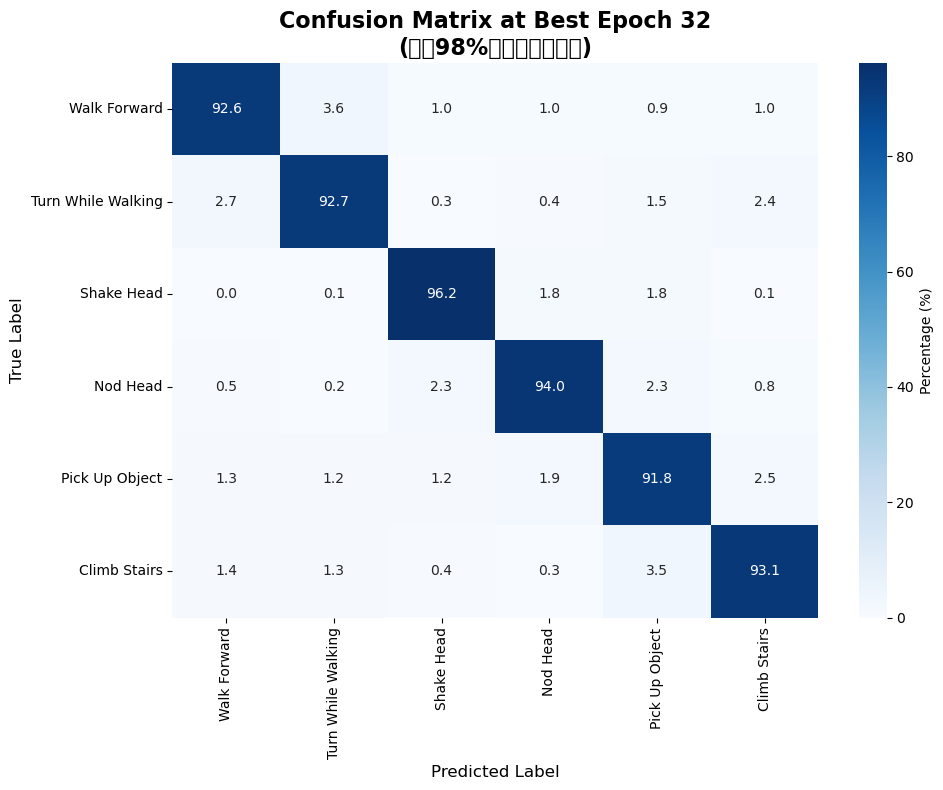


混淆矩阵（数值）:
[[651  25   7   7   6   7]
 [ 19 658   2   3  11  17]
 [  0   1 653  12  12   1]
 [  3   1  15 609  15   5]
 [  9   8   8  13 614  17]
 [ 10   9   3   2  24 645]]

混淆矩阵（百分比）:
[[92.60312945  3.55618777  0.99573257  0.99573257  0.85348506  0.99573257]
 [ 2.67605634 92.67605634  0.28169014  0.42253521  1.54929577  2.3943662 ]
 [ 0.          0.14727541 96.17083947  1.76730486  1.76730486  0.14727541]
 [ 0.46296296  0.15432099  2.31481481 93.98148148  2.31481481  0.77160494]
 [ 1.34529148  1.19581465  1.19581465  1.9431988  91.77877429  2.54110613]
 [ 1.44300144  1.2987013   0.43290043  0.28860029  3.46320346 93.07359307]]

各类别准确率:
Walk Forward: 92.60% (651/703)
Turn While Walking: 92.68% (658/710)
Shake Head: 96.17% (653/679)
Nod Head: 93.98% (609/648)
Pick Up Object: 91.78% (614/669)
Climb Stairs: 93.07% (645/693)


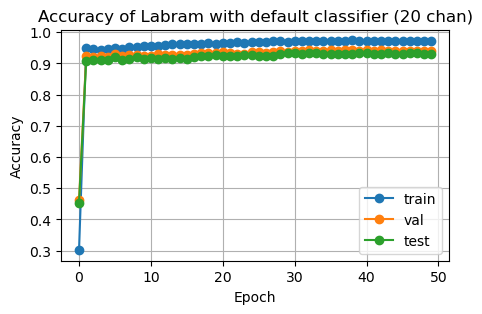

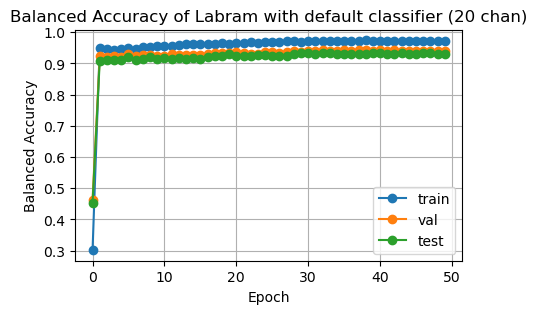

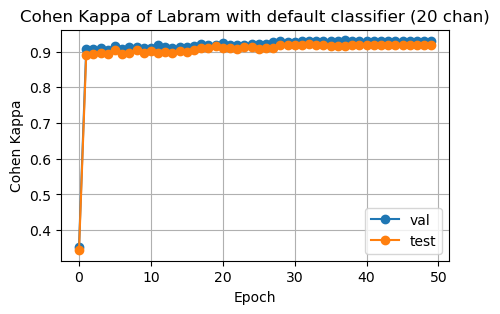

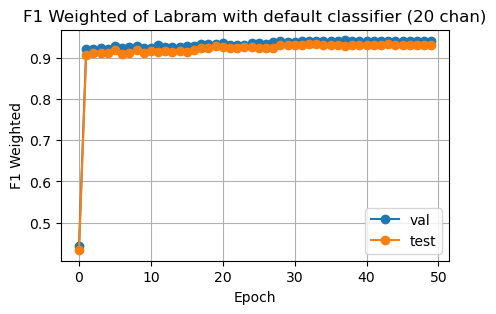

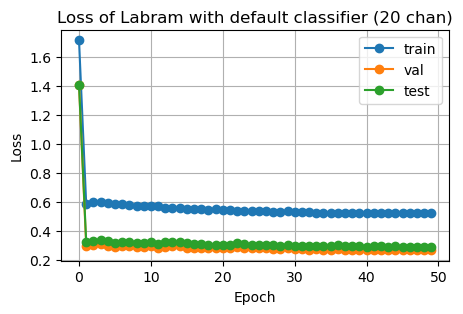

In [7]:
# Motor数据集可视化（6分类任务）
channel_size = 20
log_file = f'../new_ckpt/Motor-posWeight1.0-swien_config/expauthor-3ly-linear_probe/log.txt'

# 定义Motor数据集的类别名称（请根据实际情况修改）
# motor_class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']
motor_class_names = [
    'Walk Forward',
    'Turn While Walking',
    'Shake Head',
    'Nod Head',
    'Pick Up Object',
    'Climb Stairs'
]
# 或者使用更具体的名称，例如：
# motor_class_names = ['Left Hand', 'Right Hand', 'Both Feet', 'Tongue', 'Both Hands', 'Rest']

# 可视化（会自动显示混淆矩阵来验证98%准确率是否真实）
plot_loss_acc_result(log_file, classifier_name='default classifier', channel_size=channel_size, 
                     is_motor=True, class_names=motor_class_names, show_confusion_matrix=True)

✓ 处理了 50 个唯一epoch (范围: 0 到 49)
✓ 找到 49 个混淆矩阵 (epochs: 1 到 49)
max val acc: 0.9430735401905692, epoch is 37
test accuracy in epoch 37: 0.9297903461725987
test balanced acc in epoch 37: 0.9296960179047936
test cohen kappa in epoch 37: 0.9157280155256489
test f1_weighted in epoch 37: 0.9296801255493439
---
max test balanced acc: 0.9338064568302183, epoch is 32
test accuracy in epoch 32: 0.9336908824963432
test cohen kappa in epoch 32: 0.9204173143753744
test f1_weighted in epoch 32: 0.933705738313936

最佳epoch (32) 的混淆矩阵（用于验证模型是否真的学到了）:


/tmp/ipykernel_4619/3848335460.py:29: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4619/3848335460.py:29: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4619/3848335460.py:29: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4619/3848335460.py:29: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4619/3848335460.py:29: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4619/3848335460.py:29: UserWarning: Glyph 26159 (\N{CJK UNIFIED IDEOGRAPH-662F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4619/3848335460.py:29: UserWarning: Glyph 21542 (\N{CJK UNIFIED IDEOGRAPH-5426}) missing from current font.
  plt.tight_l

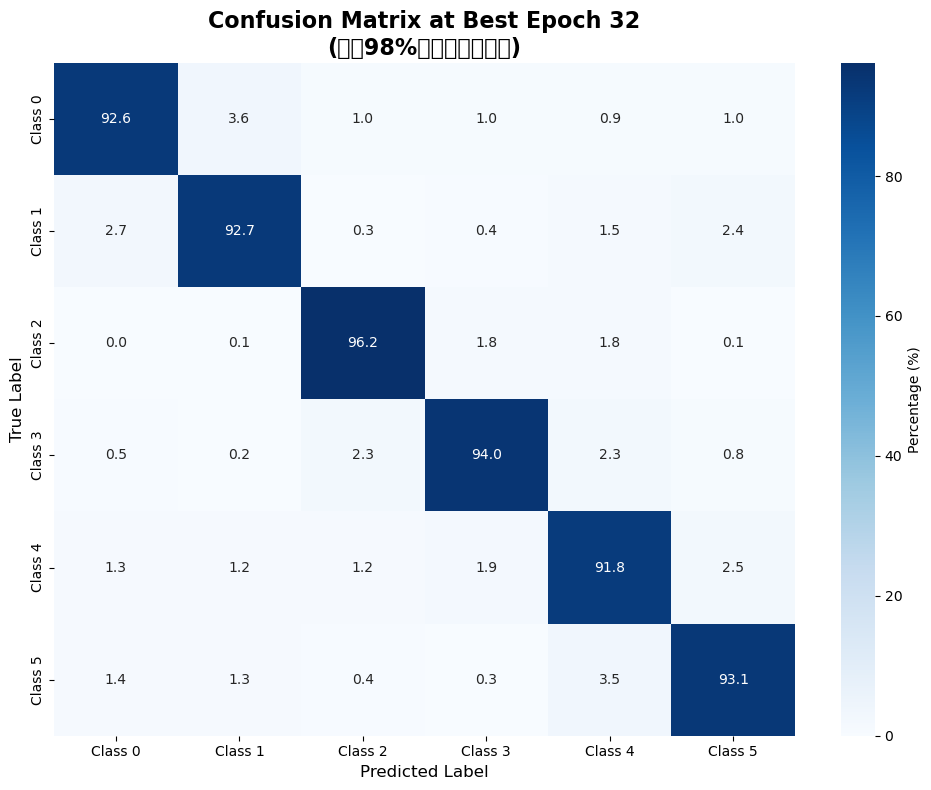


混淆矩阵（数值）:
[[651  25   7   7   6   7]
 [ 19 658   2   3  11  17]
 [  0   1 653  12  12   1]
 [  3   1  15 609  15   5]
 [  9   8   8  13 614  17]
 [ 10   9   3   2  24 645]]

混淆矩阵（百分比）:
[[92.60312945  3.55618777  0.99573257  0.99573257  0.85348506  0.99573257]
 [ 2.67605634 92.67605634  0.28169014  0.42253521  1.54929577  2.3943662 ]
 [ 0.          0.14727541 96.17083947  1.76730486  1.76730486  0.14727541]
 [ 0.46296296  0.15432099  2.31481481 93.98148148  2.31481481  0.77160494]
 [ 1.34529148  1.19581465  1.19581465  1.9431988  91.77877429  2.54110613]
 [ 1.44300144  1.2987013   0.43290043  0.28860029  3.46320346 93.07359307]]

各类别准确率:
Class 0: 92.60% (651/703)
Class 1: 92.68% (658/710)
Class 2: 96.17% (653/679)
Class 3: 93.98% (609/648)
Class 4: 91.78% (614/669)
Class 5: 93.07% (645/693)


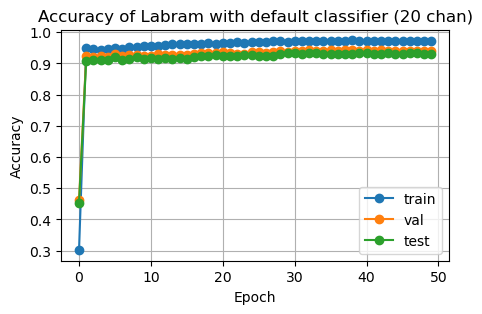

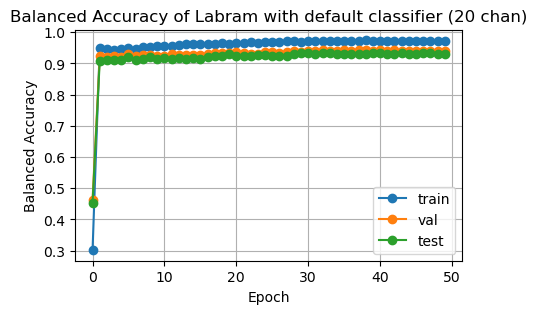

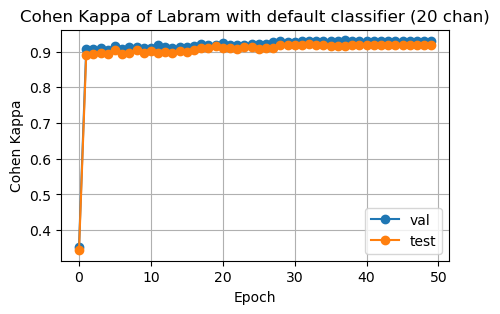

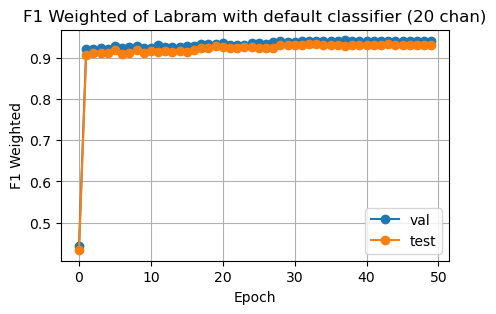

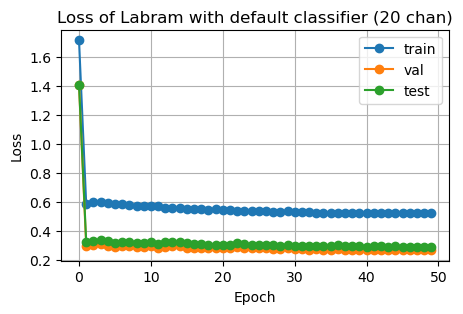

In [19]:
# Motor数据集可视化（6分类任务）
channel_size = 20
log_file = f'../new_ckpt/Motor-posWeight1.0-swien_config/expauthor-3ly-linear_probe/log.txt'

# 定义Motor数据集的类别名称（请根据实际情况修改）
motor_class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']
# 或者使用更具体的名称，例如：
# motor_class_names = ['Left Hand', 'Right Hand', 'Both Feet', 'Tongue', 'Both Hands', 'Rest']

# 可视化（会自动显示混淆矩阵来验证98%准确率是否真实）
plot_loss_acc_result(log_file, classifier_name='default classifier', channel_size=channel_size, 
                     is_motor=True, class_names=motor_class_names, show_confusion_matrix=True)

In [1]:
# Motor数据集可视化（6分类任务）
channel_size = 20
log_file = f'../new_ckpt/Motor-posWeight1.0-swien_config/expauthor-3ly-linear_probe/log.txt'

# 定义Motor数据集的类别名称（请根据实际情况修改）
motor_class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']
# 或者使用更具体的名称，例如：
# motor_class_names = ['Left Hand', 'Right Hand', 'Both Feet', 'Tongue', 'Both Hands', 'Rest']

# 可视化（会自动显示混淆矩阵来验证98%准确率是否真实）
plot_loss_acc_result(log_file, classifier_name='default classifier', channel_size=channel_size, 
                     is_motor=True, class_names=motor_class_names, show_confusion_matrix=True)

NameError: name 'plot_loss_acc_result' is not defined

In [15]:
# 示例：可视化混淆矩阵
# 方法1: 如果已经有混淆矩阵数据（numpy array格式）
# 请根据实际情况修改类别名称
motor_class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']  # 根据Motor数据集的实际类别名称修改

# 示例混淆矩阵（请替换为实际的混淆矩阵数据）
# 可以从保存的文件加载，或者从模型预测结果计算
# cm = np.load('confusion_matrix.npy')  # 如果已保存
# 或者
# cm = confusion_matrix(y_true, y_pred)  # 从真实标签和预测标签计算

# 如果已有混淆矩阵，取消下面的注释并修改
# cm = np.array([[100, 5, 2, 1, 0, 0],
#                [3, 95, 2, 0, 0, 0],
#                [1, 2, 97, 0, 0, 0],
#                [0, 0, 0, 98, 2, 0],
#                [0, 0, 0, 1, 99, 0],
#                [0, 0, 0, 0, 1, 99]])
# plot_confusion_matrix(cm, class_names=motor_class_names, 
#                      title='Motor Dataset Confusion Matrix (Test Set)')


In [16]:
# 方法2: 从模型和测试数据计算混淆矩阵
# 如果需要从保存的模型计算混淆矩阵，可以使用以下函数
def compute_confusion_matrix_from_model(model_path, test_loader, device='cuda', num_classes=6):
    """
    从保存的模型和测试数据计算混淆矩阵
    
    参数:
    model_path: 模型文件路径
    test_loader: 测试数据加载器
    device: 设备 ('cuda' 或 'cpu')
    num_classes: 类别数量（Motor数据集为6）
    
    返回:
    confusion_matrix: 混淆矩阵
    y_true: 真实标签
    y_pred: 预测标签
    """
    import torch
    from engine_for_finetuning import evaluate
    
    # 加载模型（需要根据实际情况修改）
    # model = load_model(model_path)
    # model.eval()
    
    # 收集所有预测和真实标签
    all_preds = []
    all_labels = []
    
    # with torch.no_grad():
    #     for batch in test_loader:
    #         EEG = batch[0].to(device)
    #         labels = batch[-1].to(device)
    #         outputs = model(EEG)
    #         preds = torch.argmax(outputs, dim=1)
    #         all_preds.extend(preds.cpu().numpy())
    #         all_labels.extend(labels.cpu().numpy())
    
    # cm = confusion_matrix(all_labels, all_preds)
    # return cm, all_labels, all_preds
    
    # 注意：上面的代码需要根据实际的模型加载方式修改
    pass

# 使用示例（需要根据实际情况修改）:
# cm, y_true, y_pred = compute_confusion_matrix_from_model(
#     model_path='path/to/model.pth',
#     test_loader=test_loader,
#     device='cuda',
#     num_classes=6
# )
# plot_confusion_matrix(cm, class_names=motor_class_names, 
#                      title='Motor Dataset Confusion Matrix (Test Set)')


In [ ]:
# 方法3: 如果混淆矩阵已保存在文件中（例如numpy格式或文本格式）

def load_confusion_matrix_from_file(file_path, format='numpy'):
    """
    从文件加载混淆矩阵
    
    参数:
    file_path: 文件路径
    format: 文件格式 ('numpy', 'csv', 'txt')
    """
    if format == 'numpy':
        cm = np.load(file_path)
    elif format == 'csv':
        cm = np.loadtxt(file_path, delimiter=',')
    elif format == 'txt':
        cm = np.loadtxt(file_path)
    else:
        raise ValueError(f"Unsupported format: {format}")
    return cm

# 使用示例:
# cm = load_confusion_matrix_from_file('confusion_matrix.npy', format='numpy')
# plot_confusion_matrix(cm, class_names=motor_class_names, 
#                      title='Motor Dataset Confusion Matrix (Test Set)')


In [ ]:
# 完整的Motor数据集可视化示例（包括混淆矩阵）
# 如果已有混淆矩阵数据，可以直接使用以下代码

# 步骤1: 定义Motor数据集的类别名称（请根据实际情况修改）
motor_class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']
# 或者使用更具体的名称，例如：
# motor_class_names = ['Left Hand', 'Right Hand', 'Both Feet', 'Tongue', 'Both Hands', 'Rest']

# 步骤2: 加载或计算混淆矩阵
# 选项A: 如果混淆矩阵已保存为numpy文件
# cm = load_confusion_matrix_from_file('path/to/confusion_matrix.npy', format='numpy')

# 选项B: 如果混淆矩阵已保存为CSV文件
# cm = load_confusion_matrix_from_file('path/to/confusion_matrix.csv', format='csv')

# 选项C: 如果已有真实标签和预测标签
# cm = confusion_matrix(y_true, y_pred)

# 步骤3: 可视化混淆矩阵
# plot_confusion_matrix(cm, class_names=motor_class_names, 
#                      title='Motor Dataset Confusion Matrix (Test Set)')

print("请根据实际情况修改上面的代码，取消注释并填入正确的路径或数据")


In [ ]:
# 方法4: 从保存的模型计算混淆矩阵（推荐方法）
# 由于log文件中没有保存混淆矩阵，我们可以从保存的模型重新计算

import sys
import os
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))

# 配置参数（请根据实际情况修改）
model_path = '../new_ckpt/Motor-posWeight1.0-swien_config/expauthor-3ly-all/checkpoint-best.pth'
dataset_path = '/dsmlp/home-fs03/14/114/xuz056/LEM/motor/test_pipeline/siwen_labram_finetune/data'  # 请修改为实际的数据集路径
output_dir = '../new_ckpt/Motor-posWeight1.0-swien_config/expauthor-3ly-all/confusion_matrix'  # 保存混淆矩阵的目录

print("注意：这个方法需要运行compute_confusion_matrix.py脚本")
print("可以在终端运行以下命令：")
print(f"python compute_confusion_matrix.py --model_path {model_path} --dataset_path {dataset_path} --output_dir {output_dir}")
print("\n或者使用下面的函数直接计算（需要导入相关模块）")


In [ ]:
# 使用计算好的混淆矩阵进行可视化
# 如果已经运行了compute_confusion_matrix.py脚本，可以直接加载结果

# 配置路径（请根据实际情况修改）
confusion_matrix_dir = '../new_ckpt/Motor-posWeight1.0-swien_config/expauthor-3ly-all/confusion_matrix'
cm_file = os.path.join(confusion_matrix_dir, 'confusion_matrix.npy')

# 检查文件是否存在
if os.path.exists(cm_file):
    # 加载混淆矩阵
    cm = load_confusion_matrix_from_file(cm_file, format='numpy')
    
    # 定义类别名称（请根据Motor数据集的实际类别修改）
    motor_class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']
    # 或者使用更具体的名称，例如：
    # motor_class_names = ['Left Hand', 'Right Hand', 'Both Feet', 'Tongue', 'Both Hands', 'Rest']
    
    # 可视化混淆矩阵
    plot_confusion_matrix(cm, class_names=motor_class_names, 
                         title='Motor Dataset Confusion Matrix (Test Set)')
else:
    print(f"混淆矩阵文件不存在: {cm_file}")
    print("请先运行 compute_confusion_matrix.py 脚本生成混淆矩阵")
    print("或者使用下面的代码从模型直接计算")


## 使用说明

### 方法1: 使用命令行脚本计算混淆矩阵（推荐）

在终端运行：
```bash
cd "Code For Visualization"
python compute_confusion_matrix.py \
    --model_path ../new_ckpt/Motor-posWeight1.0-swien_config/expauthor-3ly-all/checkpoint-best.pth \
    --dataset_path /path/to/your/dataset \
    --output_dir ../new_ckpt/Motor-posWeight1.0-swien_config/expauthor-3ly-all/confusion_matrix
```

### 方法2: 在notebook中直接加载已计算的混淆矩阵

如果已经运行了上面的脚本，可以直接在Cell 11中加载和可视化混淆矩阵。

### 方法3: 从JSON文件加载（如果compute_confusion_matrix.py保存了JSON）

如果compute_confusion_matrix.py保存了predictions.json，也可以从那里加载：


In [ ]:
# 方法5: 从JSON文件加载预测结果（如果compute_confusion_matrix.py保存了JSON）
predictions_file = '../new_ckpt/Motor-posWeight1.0-swien_config/expauthor-3ly-all/confusion_matrix/predictions.json'

if os.path.exists(predictions_file):
    with open(predictions_file, 'r') as f:
        results = json.load(f)
    
    y_true = results['y_true']
    y_pred = results['y_pred']
    cm = np.array(results['confusion_matrix'])
    
    # 可视化混淆矩阵
    motor_class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']
    plot_confusion_matrix(cm, class_names=motor_class_names, 
                         title='Motor Dataset Confusion Matrix (Test Set)')
else:
    print(f"预测结果文件不存在: {predictions_file}")
    print("请先运行 compute_confusion_matrix.py 脚本")
